In [1]:
!pip install -q albumentations --upgrade

In [2]:
import numpy as np
import pandas as pd
import cv2
import glob
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score)
import albumentations as A
import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Input)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import Sequence

import random
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))
from tensorflow.keras import mixed_precision
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision ENABLED (GPU detected)")
else:
    print("No GPU detected - skipping mixed precision")

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision ENABLED (GPU detected)


In [3]:
import os

def find_train_test_dirs(root="/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia"):
    """Recursively locate the 'train' and 'test' folders (each containing NORMAL/PNEUMONIA subfolders)."""
    train_dir, test_dir = None, None
    for dirpath, dirnames, _ in os.walk(root):
        if "NORMAL" in dirnames and "PNEUMONIA" in dirnames:
            base_name = os.path.basename(dirpath).lower()
            if "train" in base_name:
                train_dir = dirpath
            elif "test" in base_name:
                test_dir = dirpath
    return train_dir, test_dir

TRAIN_DIR, TEST_DIR = find_train_test_dirs()
assert TRAIN_DIR is not None and TEST_DIR is not None, "train/test folders not found — check that the dataset was added via 'Add Input'"
print("Train dir:", TRAIN_DIR)
print("Test dir:", TEST_DIR)

Train dir: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train
Test dir: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test


In [4]:
# Kaggle's writable/persisted output directory - checkpoints get saved here
os.chdir("/kaggle/working")
print("Working dir:", os.getcwd())

Working dir: /kaggle/working


In [5]:
def build_dataframe(root_dir, split_name):
    records = []
    label_map = {"NORMAL": 0, "PNEUMONIA": 1}
    for label_name, class_id in label_map.items():
        class_folder = os.path.join(root_dir, label_name)
        if not os.path.isdir(class_folder):
            continue
        valid_ext = (".jpeg", ".jpg", ".png", ".bmp")
        for fname in os.listdir(class_folder):
            if fname.lower().endswith(valid_ext):
                fpath = os.path.join(class_folder, fname)
                records.append({"image_path": fpath, "label": label_name,
                                 "class_id": class_id, "split": split_name})
    return pd.DataFrame(records)

train_df_raw = build_dataframe(TRAIN_DIR, "train")
test_df_raw = build_dataframe(TEST_DIR, "test")
universal_df = pd.concat([train_df_raw, test_df_raw], ignore_index=True)
universal_df = universal_df.sample(frac=1, random_state=SEED).reset_index(drop=True) 
print("Total images found:", len(universal_df))
universal_df.head()

Total images found: 5840


,image_path,label,class_id,split
0,/kaggle/input/datasets/paultimothymooney/chest...,PNEUMONIA,1,train
1,/kaggle/input/datasets/paultimothymooney/chest...,NORMAL,0,train
2,/kaggle/input/datasets/paultimothymooney/chest...,NORMAL,0,train
3,/kaggle/input/datasets/paultimothymooney/chest...,PNEUMONIA,1,train
4,/kaggle/input/datasets/paultimothymooney/chest...,PNEUMONIA,1,train


In [6]:
from concurrent.futures import ThreadPoolExecutor

def is_valid_image(path):
    img = cv2.imread(path)
    return img is not None

with ThreadPoolExecutor(max_workers=16) as executor:  # I/O-bound, so threads parallelize the disk reads well
    validity_results = list(executor.map(is_valid_image, universal_df["image_path"]))
universal_df["is_valid"] = validity_results
print("Corrupt/unreadable images:", (~universal_df["is_valid"]).sum())
universal_df = universal_df[universal_df["is_valid"]].drop(columns=["is_valid"]).reset_index(drop=True)
print("Final clean dataset size:", len(universal_df))

Corrupt/unreadable images: 0
Final clean dataset size: 5840


## Exploratory Data Analysis (EDA)


/tmp/ipykernel_58/1622803333.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0], palette="viridis")


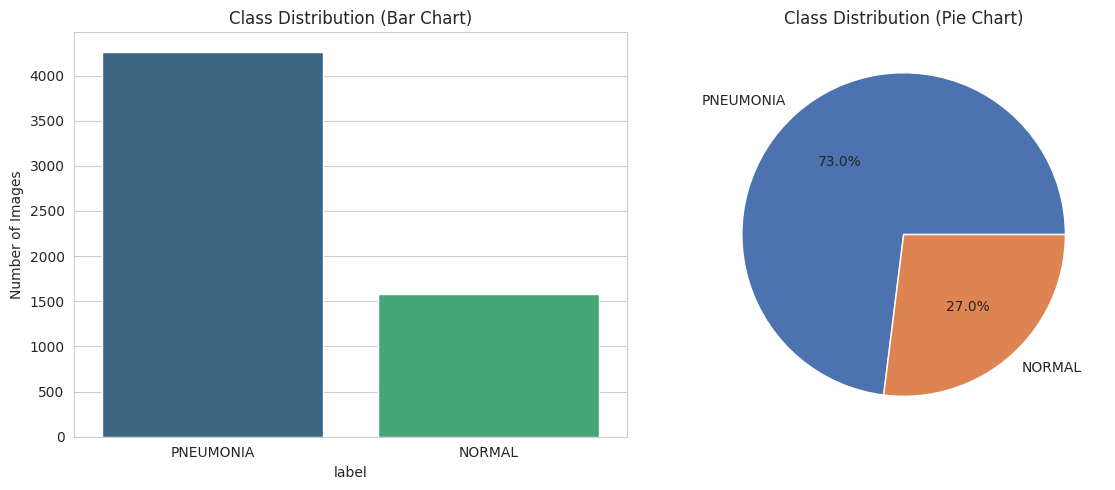

Class Imbalance Ratio: 2.71 : 1


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
class_counts = universal_df["label"].value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0], palette="viridis")
axes[0].set_title("Class Distribution (Bar Chart)")
axes[0].set_ylabel("Number of Images")
axes[1].pie(class_counts.values, labels=class_counts.index, autopct="%1.1f%%", colors=["#4C72B0", "#DD8452"])
axes[1].set_title("Class Distribution (Pie Chart)")
plt.tight_layout(); plt.show()

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Class Imbalance Ratio: {imbalance_ratio:.2f} : 1")

In [8]:
print("===== Dataset Summary =====")
print("Total images:", len(universal_df))
print(universal_df["label"].value_counts())
print()
ext_series = universal_df["image_path"].apply(lambda p: Path(p).suffix.lower())
print("Image format distribution:")
print(ext_series.value_counts())

===== Dataset Summary =====
Total images: 5840
label
PNEUMONIA    4265
NORMAL       1575
Name: count, dtype: int64

Image format distribution:
image_path
.jpeg    5840
Name: count, dtype: int64


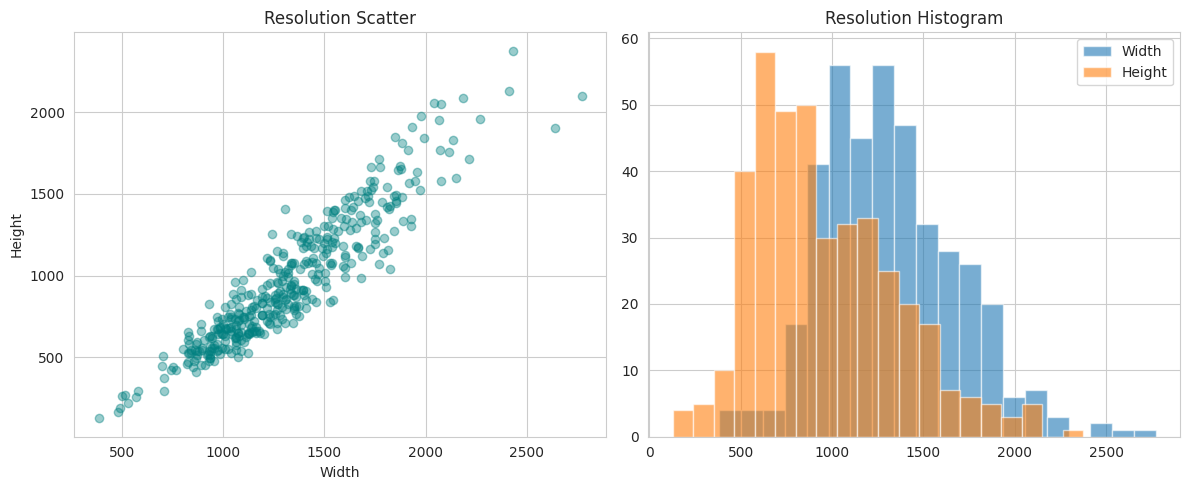

In [9]:
# Image resolution distribution (sampled to 400 images for speed)
sample_for_res = universal_df.sample(n=min(400, len(universal_df)), random_state=SEED)
widths, heights = [], []
for p in sample_for_res["image_path"]:
    img = cv2.imread(p)
    h, w = img.shape[:2]
    widths.append(w); heights.append(h)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(widths, heights, alpha=0.4, color="teal")
axes[0].set_xlabel("Width"); axes[0].set_ylabel("Height"); axes[0].set_title("Resolution Scatter")
axes[1].hist(widths, bins=20, alpha=0.6, label="Width")
axes[1].hist(heights, bins=20, alpha=0.6, label="Height")
axes[1].set_title("Resolution Histogram"); axes[1].legend()
plt.tight_layout(); plt.show()

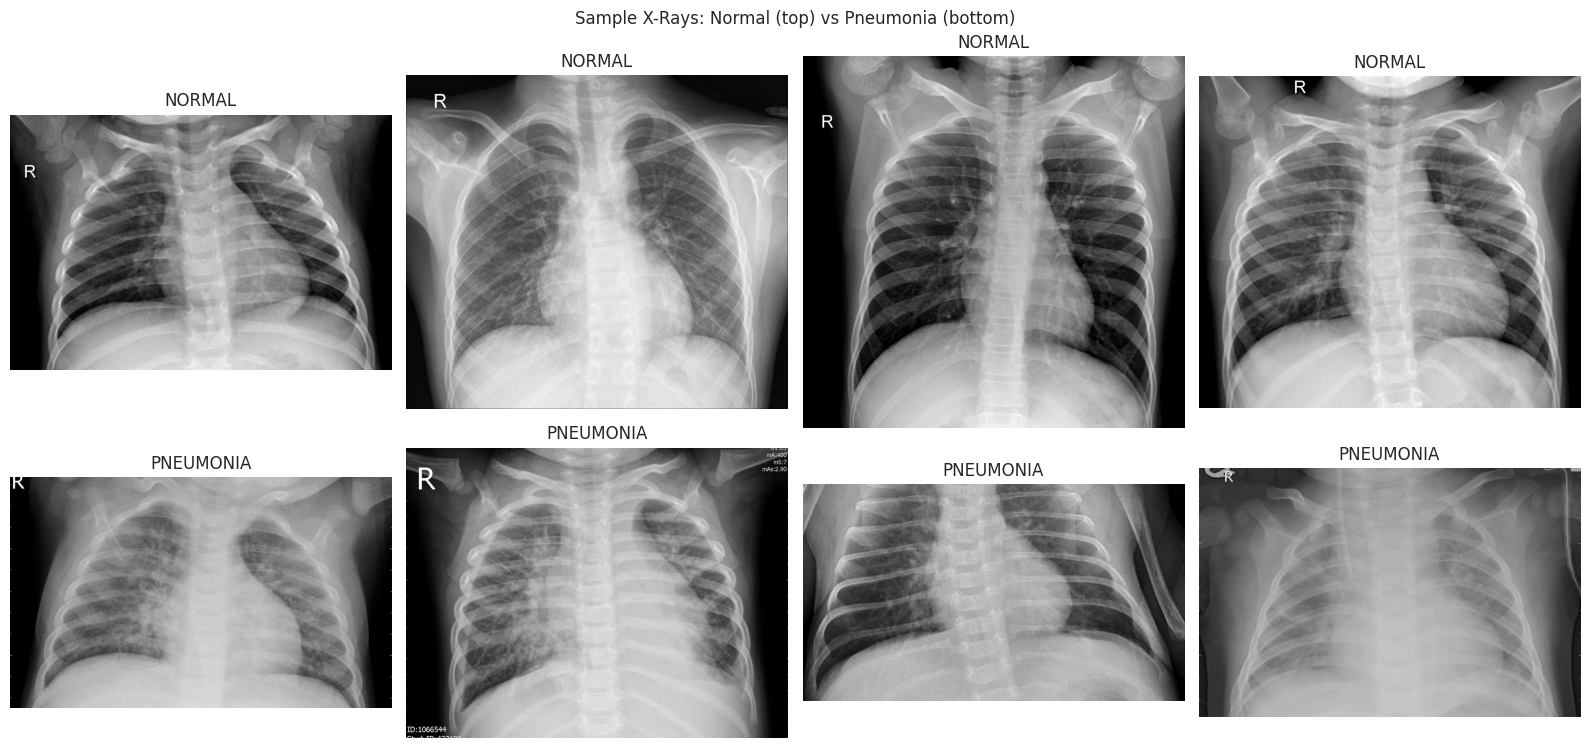

In [10]:
# Sample visualizations - 4 Normal vs 4 Pneumonia images
normal_samples = universal_df[universal_df["label"] == "NORMAL"].sample(4, random_state=SEED)
pneumonia_samples = universal_df[universal_df["label"] == "PNEUMONIA"].sample(4, random_state=SEED)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, (_, row) in enumerate(normal_samples.iterrows()):
    img = cv2.cvtColor(cv2.imread(row["image_path"]), cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img); axes[0, i].set_title("NORMAL"); axes[0, i].axis("off")
for i, (_, row) in enumerate(pneumonia_samples.iterrows()):
    img = cv2.cvtColor(cv2.imread(row["image_path"]), cv2.COLOR_BGR2RGB)
    axes[1, i].imshow(img); axes[1, i].set_title("PNEUMONIA"); axes[1, i].axis("off")
plt.suptitle("Sample X-Rays: Normal (top) vs Pneumonia (bottom)")
plt.tight_layout(); plt.show()

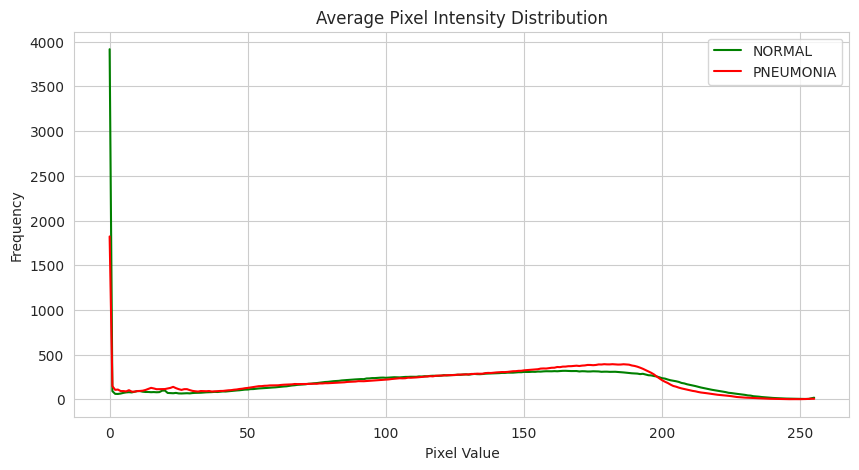

In [11]:
# Pixel intensity distribution - Normal vs Pneumonia average histogram
def avg_intensity_hist(paths, bins=256):
    hist_sum = np.zeros(bins)
    for p in paths:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (224, 224))
        h = cv2.calcHist([img], [0], None, [bins], [0, 256]).flatten()
        hist_sum += h
    return hist_sum / len(paths)

sample_normal = universal_df[universal_df["label"] == "NORMAL"].sample(min(150, class_counts["NORMAL"]), random_state=SEED)
sample_pneu = universal_df[universal_df["label"] == "PNEUMONIA"].sample(min(150, class_counts["PNEUMONIA"]), random_state=SEED)
hist_normal = avg_intensity_hist(sample_normal["image_path"].tolist())
hist_pneu = avg_intensity_hist(sample_pneu["image_path"].tolist())

plt.figure(figsize=(10, 5))
plt.plot(hist_normal, label="NORMAL", color="green")
plt.plot(hist_pneu, label="PNEUMONIA", color="red")
plt.title("Average Pixel Intensity Distribution"); plt.xlabel("Pixel Value"); plt.ylabel("Frequency"); plt.legend()
plt.show()

##Preprocessing Pipeline (Medical-Safe)


In [12]:
def crop_chest_region(img_gray):
    h_img, w_img = img_gray.shape[:2]
    _, thresh = cv2.threshold(img_gray, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return img_gray
    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)

    area_ratio = (w * h) / (w_img * h_img)
    if w < 30 or h < 30 or area_ratio < 0.5:
        return img_gray
    return img_gray[y:y + h, x:x + w]


def apply_clahe(img_gray):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(img_gray)


def preprocess_xray(image_path, target_size=(224, 224)):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    cropped = crop_chest_region(img)
    enhanced = apply_clahe(cropped)
    resized = cv2.resize(enhanced, target_size, interpolation=cv2.INTER_AREA)
    rgb_img = cv2.cvtColor(resized, cv2.COLOR_GRAY2RGB)  
    return rgb_img


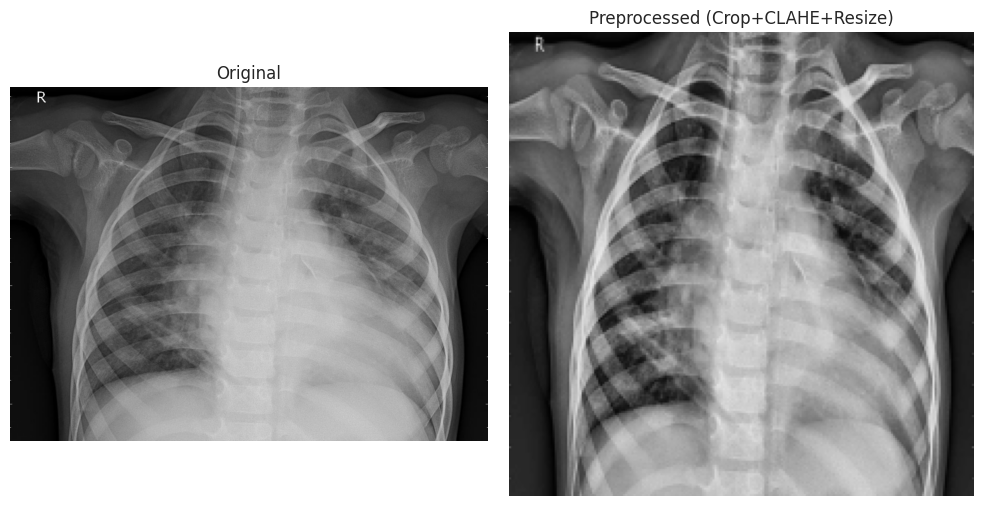

In [13]:
# Before/after preprocessing demo
sample_path = universal_df.iloc[0]["image_path"]
original = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)
processed = preprocess_xray(sample_path)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(processed); axes[1].set_title("Preprocessed (Crop+CLAHE+Resize)"); axes[1].axis("off")
plt.tight_layout(); plt.show()

In [14]:
train_full_df = universal_df[universal_df["split"] == "train"].reset_index(drop=True)
test_split_df = universal_df[universal_df["split"] == "test"].reset_index(drop=True)

train_split_df, val_split_df = train_test_split(
    train_full_df, test_size=0.15, stratify=train_full_df["class_id"], random_state=SEED
)
train_split_df = train_split_df.reset_index(drop=True)
val_split_df = val_split_df.reset_index(drop=True)

print(f"Train: {len(train_split_df)} ({len(train_split_df)/len(universal_df):.1%})")
print(f"Val:   {len(val_split_df)} ({len(val_split_df)/len(universal_df):.1%})")
print(f"Test:  {len(test_split_df)} ({len(test_split_df)/len(universal_df):.1%})  <- original Kaggle test set, untouched")

print("\nClass balance check (proportion of PNEUMONIA):")
for name, d in [("Train", train_split_df), ("Val", val_split_df), ("Test", test_split_df)]:
    print(f"{name}: {(d['class_id']==1).mean():.3f}")

overlap_tv = set(train_split_df.image_path) & set(val_split_df.image_path)
overlap_tt = set(train_split_df.image_path) & set(test_split_df.image_path)
overlap_vt = set(val_split_df.image_path) & set(test_split_df.image_path)
print("\nOverlap Train-Val:", len(overlap_tv), "| Train-Test:", len(overlap_tt), "| Val-Test:", len(overlap_vt))
assert len(overlap_tv) == 0 and len(overlap_tt) == 0 and len(overlap_vt) == 0, "Data leakage detected!"
print(" No data leakage confirmed across Train/Val/Test splits.")


Train: 4433 (75.9%)
Val:   783 (13.4%)
Test:  624 (10.7%)  <- original Kaggle test set, untouched

Class balance check (proportion of PNEUMONIA):
Train: 0.743
Val: 0.743
Test: 0.625

Overlap Train-Val: 0 | Train-Test: 0 | Val-Test: 0
 No data leakage confirmed across Train/Val/Test splits.


In [15]:
IMG_SIZE = 224

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10, rotate_limit=15, p=0.5,
                        border_mode=cv2.BORDER_CONSTANT),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.CoarseDropout(num_holes_range=(1, 2), hole_height_range=(4, 10), hole_width_range=(4, 10), p=0.2),
])

val_test_transform = None  
print("Train and val/test transforms defined.")


Train and val/test transforms defined.


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [16]:
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess_input
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess_input
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess_input

PREPROCESS_FNS = { "VGG16": vgg16_preprocess_input, "ResNet50": resnet50_preprocess_input, "EfficientNetB0": efficientnet_preprocess_input,}

def preprocess_and_augment(path_tensor, label_tensor, transform):
    path = path_tensor.numpy().decode("utf-8")
    img = preprocess_xray(path, target_size=(IMG_SIZE, IMG_SIZE))
    if transform is not None:
        img = transform(image=img)["image"]
    return img.astype(np.float32), np.float32(label_tensor.numpy())


def make_tf_dataset(dataframe, transform, preprocess_fn, batch_size=32, shuffle=True):
    paths = dataframe["image_path"].values
    labels = dataframe["class_id"].values.astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED, reshuffle_each_iteration=True)

    def _map_fn(path, label):
        img, lbl = tf.py_function(
            func=lambda p, l: preprocess_and_augment(p, l, transform),
            inp=[path, label], Tout=[tf.float32, tf.float32]
        )
        img.set_shape([IMG_SIZE, IMG_SIZE, 3])
        lbl.set_shape([])
        img = preprocess_fn(img)  
        return img, lbl

    ds = ds.map(_map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


BATCH_SIZE = 32
datasets = {}
for model_name, preprocess_fn in PREPROCESS_FNS.items():
    datasets[model_name] = { "train": make_tf_dataset(train_split_df, train_transform, preprocess_fn, BATCH_SIZE, shuffle=True), "val": make_tf_dataset(val_split_df, val_test_transform, preprocess_fn, BATCH_SIZE, shuffle=False), "test": make_tf_dataset(test_split_df, val_test_transform, preprocess_fn, BATCH_SIZE, shuffle=False), "train_eval": make_tf_dataset(train_split_df, val_test_transform, preprocess_fn, BATCH_SIZE, shuffle=False),}
print("tf.data pipelines ready per backbone -> Train batches:", -(-len(train_split_df) // BATCH_SIZE),
      "| Val batches:", -(-len(val_split_df) // BATCH_SIZE), "| Test batches:", -(-len(test_split_df) // BATCH_SIZE))


I0000 00:00:1786972742.653259      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


tf.data pipelines ready per backbone -> Train batches: 139 | Val batches: 25 | Test batches: 20


In [17]:
# Class weights, computed only from the train split, to penalize the minority class during training
class_weights_arr = compute_class_weight(class_weight="balanced", classes=np.array([0, 1]), y=train_split_df["class_id"])
class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print("Computed class weights:", class_weight_dict)

Computed class weights: {0: np.float64(1.9442982456140352), 1: np.float64(0.6730944427573641)}


##  Model Training Sequence


In [18]:
def build_model(base_model_fn, model_name, input_shape=(224, 224, 3)):
    base_model = base_model_fn(weights="imagenet", include_top=False, input_shape=input_shape)
    base_model.trainable = False

    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.4)(x)
    x = BatchNormalization()(x)
    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs, name=model_name)
    model.compile( optimizer=Adam(learning_rate=1e-4), loss="binary_crossentropy", metrics=["accuracy", tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.Recall(name="recall")])
    return model

def get_callbacks(model_name):
        EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7),
        ModelCheckpoint(f"{model_name}_best.keras", monitor="val_auc", mode="max", save_best_only=True)
    ]

EPOCHS = 20

In [19]:
# Model 1 VGG16
vgg_model = build_model(VGG16, "VGG16_Pneumonia")
vgg_history = vgg_model.fit( datasets["VGG16"]["train"], validation_data=datasets["VGG16"]["val"], epochs=EPOCHS, class_weight=class_weight_dict, callbacks=get_callbacks("vgg16"), verbose=1)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/20
  2/139 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - accuracy: 0.5547 - auc: 0.5939 - loss: 0.7622 - recall: 0.5041 

I0000 00:00:1786972764.377378     155 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


139/139 ━━━━━━━━━━━━━━━━━━━━ 89s 534ms/step - accuracy: 0.7115 - auc: 0.8476 - loss: 0.4985 - recall: 0.6672 - val_accuracy: 0.8020 - val_auc: 0.9825 - val_loss: 0.4198 - val_recall: 0.7371 - learning_rate: 1.0000e-04
Epoch 2/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 63s 456ms/step - accuracy: 0.8261 - auc: 0.9508 - loss: 0.3191 - recall: 0.7865 - val_accuracy: 0.8940 - val_auc: 0.9877 - val_loss: 0.2785 - val_recall: 0.8608 - learning_rate: 1.0000e-04
Epoch 3/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 81s 447ms/step - accuracy: 0.8665 - auc: 0.9641 - loss: 0.2681 - recall: 0.8391 - val_accuracy: 0.9285 - val_auc: 0.9894 - val_loss: 0.1977 - val_recall: 0.9072 - learning_rate: 1.0000e-04
Epoch 4/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 61s 437ms/step - accuracy: 0.8807 - auc: 0.9714 - loss: 0.2362 - recall: 0.8567 - val_accuracy: 0.9400 - val_auc: 0.9908 - val_loss: 0.1731 - val_recall: 0.9227 - learning_rate: 1.0000e-04
Epoch 5/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 61s 439ms/step - accuracy: 0.8998 - auc: 0.9791 - loss:

In [20]:
# Model 2 ResNet50
resnet_model = build_model(ResNet50, "ResNet50_Pneumonia")
resnet_history = resnet_model.fit( datasets["ResNet50"]["train"], validation_data=datasets["ResNet50"]["val"], epochs=EPOCHS, class_weight=class_weight_dict, callbacks=get_callbacks("resnet50"), verbose=1)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 92s 537ms/step - accuracy: 0.8193 - auc: 0.9467 - loss: 0.3328 - recall: 0.7774 - val_accuracy: 0.9361 - val_auc: 0.9910 - val_loss: 0.1998 - val_recall: 0.9158 - learning_rate: 1.0000e-04
Epoch 2/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 60s 430ms/step - accuracy: 0.8967 - auc: 0.9767 - loss: 0.2253 - recall: 0.8734 - val_accuracy: 0.9438 - val_auc: 0.9923 - val_loss: 0.1850 - val_recall: 0.9278 - learning_rate: 1.0000e-04
Epoch 3/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 59s 426ms/step - accuracy: 0.9206 - auc: 0.9826 - loss: 0.1869 - recall: 0.9083 - val_accuracy: 0.9464 - val_auc: 0.9934 - val_loss: 0.1883 - val_recall: 0.9296 - learning_rate: 1.0000e-04
Epoch 4/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 59s 422ms/step - accuracy: 0.9350 - auc: 0.9856 - loss: 0.1664 - recall: 0.9238 - val_accuracy: 0.9655 - val_auc: 0.9935 - val_loss: 0.1252 - val_recall: 0.9622 - learning_rate: 1.0000e-04
Epoch 5/20
139/139 ━━━━━━━━━━━━━━

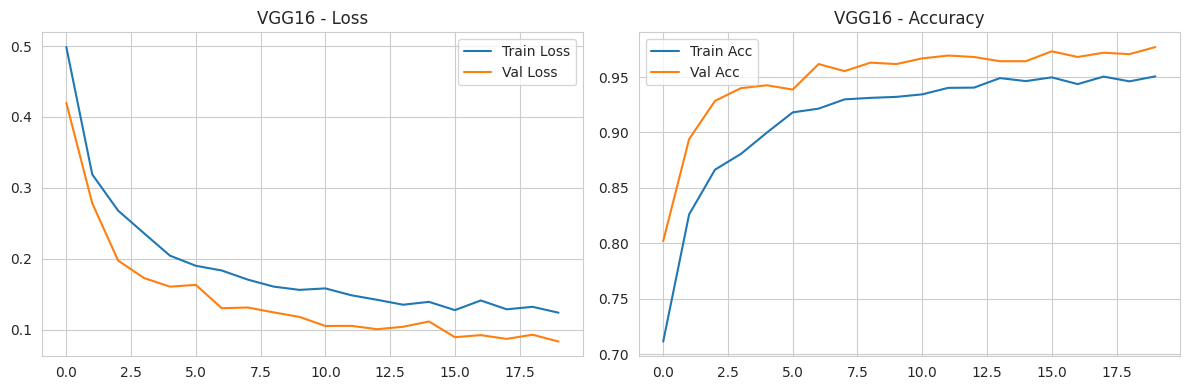

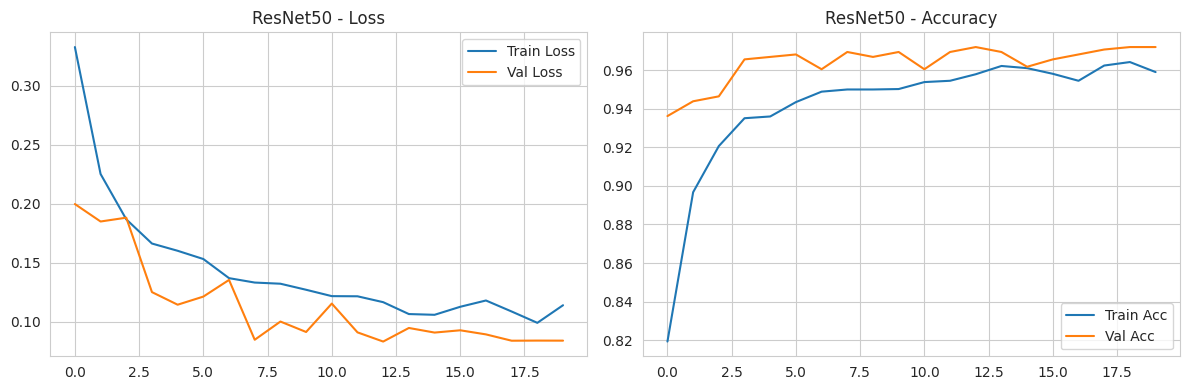

In [22]:
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["loss"], label="Train Loss")
    axes[0].plot(history.history["val_loss"], label="Val Loss")
    axes[0].set_title(f"{model_name} - Loss"); axes[0].legend()
    axes[1].plot(history.history["accuracy"], label="Train Acc")
    axes[1].plot(history.history["val_accuracy"], label="Val Acc")
    axes[1].set_title(f"{model_name} - Accuracy"); axes[1].legend()
    plt.tight_layout(); plt.show()

plot_history(vgg_history, "VGG16")
plot_history(resnet_history, "ResNet50")


In [23]:
def get_predictions(model, dataset):
    y_true, y_prob = [], []
    for X_batch, y_batch in dataset:
        preds = model.predict(X_batch, verbose=0)
        y_true.extend(y_batch.numpy())
        y_prob.extend(preds.flatten())
    return np.array(y_true), np.array(y_prob)


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
    }


models_dict = {"VGG16": vgg_model, "ResNet50": resnet_model }
results = {}
for name, model in models_dict.items():
    ds = datasets[name]
    y_train_true, y_train_prob = get_predictions(model, ds["train_eval"])
    y_test_true, y_test_prob = get_predictions(model, ds["test"])
    train_metrics = compute_metrics(y_train_true, y_train_prob)
    test_metrics = compute_metrics(y_test_true, y_test_prob)
    fpr, tpr, _ = roc_curve(y_test_true, y_test_prob)
    test_auc = auc(fpr, tpr)
    results[name] = {"train": train_metrics, "test": test_metrics, "auc": test_auc,
                      "y_test_true": y_test_true, "y_test_prob": y_test_prob, "fpr": fpr, "tpr": tpr}
    print(f"\n===== {name} =====")
    print("Train:", train_metrics)
    print("Test :", test_metrics, "| AUC:", round(test_auc, 4))



===== VGG16 =====
Train: {'Accuracy': 0.9693210015790661, 'Precision': 0.9943626683369872, 'Recall': 0.9641664136046159, 'F1-Score': 0.979031760715387}
Test : {'Accuracy': 0.8573717948717948, 'Precision': 0.8278867102396514, 'Recall': 0.9743589743589743, 'F1-Score': 0.8951707891637221} | AUC: 0.9441

===== ResNet50 =====
Train: {'Accuracy': 0.9781186555380104, 'Precision': 0.995350278983261, 'Recall': 0.9750986941998178, 'F1-Score': 0.9851204172419082}
Test : {'Accuracy': 0.8557692307692307, 'Precision': 0.8260869565217391, 'Recall': 0.9743589743589743, 'F1-Score': 0.8941176470588236} | AUC: 0.9505


In [24]:
# Classification reports (test set) for each model
for name, res in results.items():
    print(f"\n===== Classification Report: {name} (Test Set) =====")
    y_pred = (res["y_test_prob"] >= 0.5).astype(int)
    print(classification_report(res["y_test_true"], y_pred, target_names=["NORMAL", "PNEUMONIA"]))


===== Classification Report: VGG16 (Test Set) =====
              precision    recall  f1-score   support

      NORMAL       0.94      0.66      0.78       234
   PNEUMONIA       0.83      0.97      0.90       390

    accuracy                           0.86       624
   macro avg       0.88      0.82      0.84       624
weighted avg       0.87      0.86      0.85       624


===== Classification Report: ResNet50 (Test Set) =====
              precision    recall  f1-score   support

      NORMAL       0.94      0.66      0.77       234
   PNEUMONIA       0.83      0.97      0.89       390

    accuracy                           0.86       624
   macro avg       0.88      0.82      0.83       624
weighted avg       0.87      0.86      0.85       624



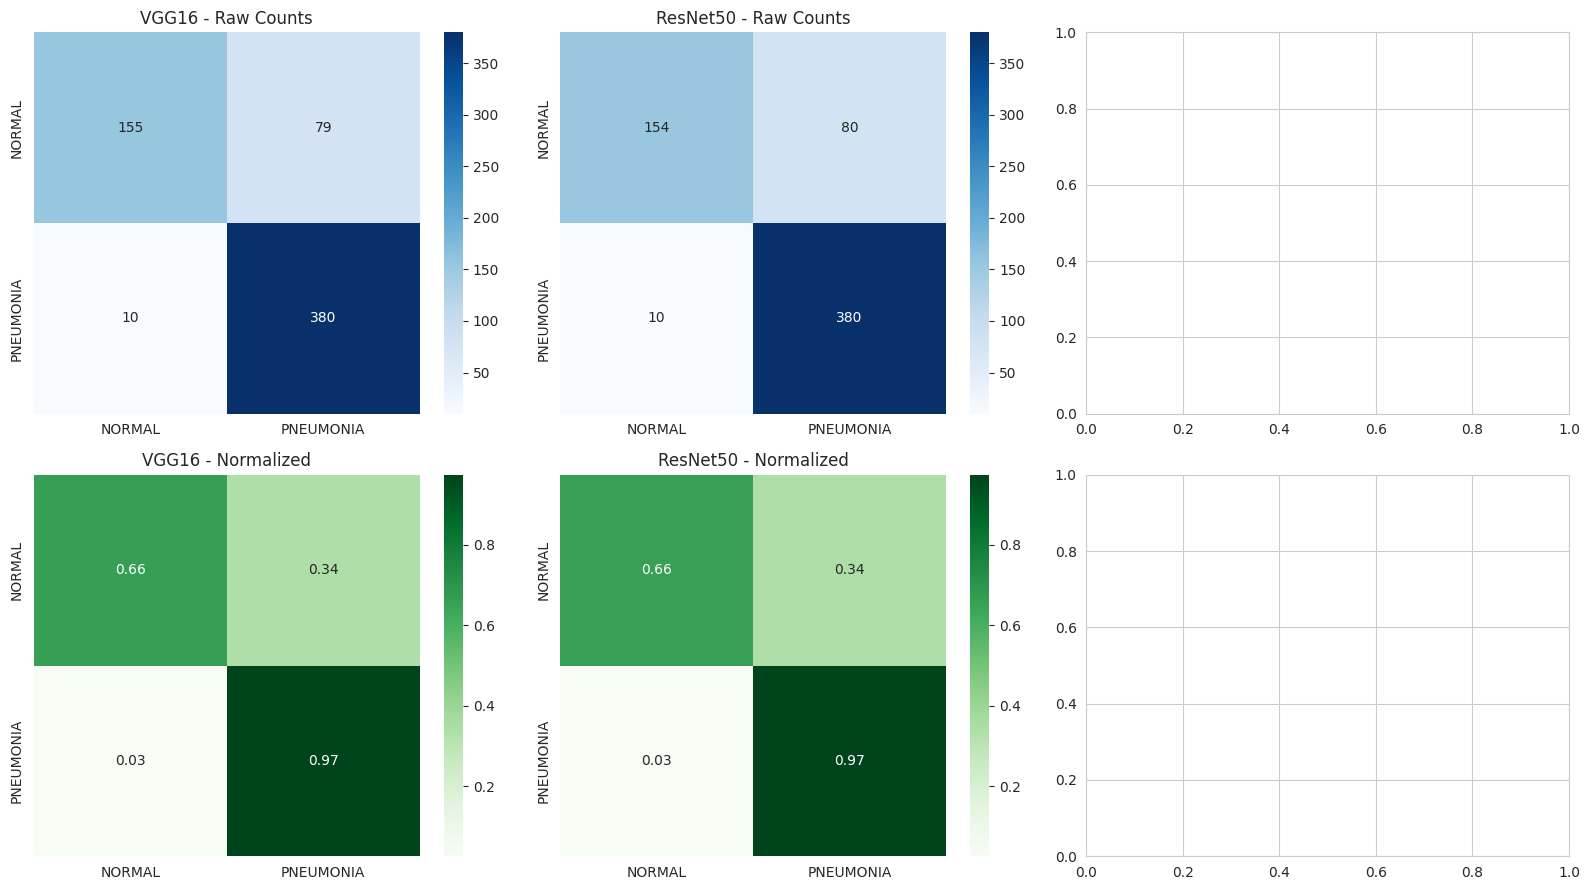

In [25]:
# Confusion matrices (raw + normalized) for all three models
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, (name, res) in enumerate(results.items()):
    y_pred = (res["y_test_prob"] >= 0.5).astype(int)
    cm_raw = confusion_matrix(res["y_test_true"], y_pred)
    cm_norm = confusion_matrix(res["y_test_true"], y_pred, normalize="true")
    sns.heatmap(cm_raw, annot=True, fmt="d", cmap="Blues", ax=axes[0, i],
                xticklabels=["NORMAL", "PNEUMONIA"], yticklabels=["NORMAL", "PNEUMONIA"])
    axes[0, i].set_title(f"{name} - Raw Counts")
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens", ax=axes[1, i],
                xticklabels=["NORMAL", "PNEUMONIA"], yticklabels=["NORMAL", "PNEUMONIA"])
    axes[1, i].set_title(f"{name} - Normalized")
plt.tight_layout(); plt.show()

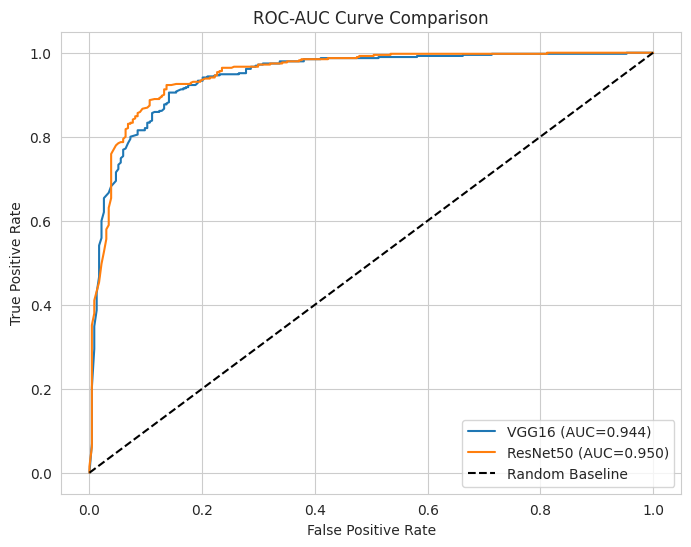

In [26]:
# ROC-AUC curves - all three models on one plot for comparison
plt.figure(figsize=(8, 6))
for name, res in results.items():
    plt.plot(res["fpr"], res["tpr"], label=f"{name} (AUC={res['auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Baseline")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve Comparison"); plt.legend()
plt.show()

In [27]:
# Final model comparison table
comparison_rows = []
for name, res in results.items():
    row = {"Model": name, **{f"Test {k}": round(v, 4) for k, v in res["test"].items()}, "AUC": round(res["auc"], 4)}
    comparison_rows.append(row)
comparison_df = pd.DataFrame(comparison_rows).sort_values("AUC", ascending=False).reset_index(drop=True)
best_model_name = comparison_df.iloc[0]["Model"]
print(f" Best performing architecture: {best_model_name}")
comparison_df

 Best performing architecture: ResNet50


,Model,Test Accuracy,Test Precision,Test Recall,Test F1-Score,AUC
0,ResNet50,0.8558,0.8261,0.9744,0.8941,0.9505
1,VGG16,0.8574,0.8279,0.9744,0.8952,0.9441
